# Brain Maps Across Lags for Future/Past Analysis

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import sys
sys.path.append('/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/scripts')
import tfsplt_future_past_utils as pu
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [18]:
# Configuration
res_d = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"
output_dir = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/future_past/bands_brainmaps'
# thresh_joint = 0.12
thresh_joint = 0.1

# Lags to plot (in milliseconds)
lags_to_plot = [-2000, -1000, -500, 0, 500, 1000, 2000]

# Define colormaps for each label3
colormap_colors = {
    'sentence': '#0D8D00',   # Future - medium green
    'sentence2': '#A90008',  # Past - medium red
    'word': '#AC7000',       # Word - orange
    'joint': '#092C72'       # Joint - medium blue
}

# Create colormaps from white to the target color
colormaps = {}
for key, target_color in colormap_colors.items():
    colormaps[key] = mcolors.LinearSegmentedColormap.from_list(
        f"{key}_cmap",
        ['white', target_color],
        N=256
    )

print(f"Results directory: {res_d}")
print(f"Output directory: {output_dir}")
print(f"Joint threshold: {thresh_joint}")
print(f"Lags to plot: {lags_to_plot}")
print(f"\nColormaps created for:")
for key in colormaps.keys():
    print(f"  {key}: white -> {colormap_colors[key]}")

Results directory: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs
Output directory: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/future_past/bands_brainmaps
Joint threshold: 0.1
Lags to plot: [-2000, -1000, -500, 0, 500, 1000, 2000]

Colormaps created for:
  sentence: white -> #0D8D00
  sentence2: white -> #A90008
  word: white -> #AC7000
  joint: white -> #092C72


## Load Data

In [19]:
# Load comprehension data
print("Loading comprehension data...")
comp_data = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv",
    thresh_joint
)
print(f"Comprehension data shape: {comp_data.shape}")

Loading comprehension data...
Comprehension data shape: (1168, 2406)


In [20]:
# Load production data
print("Loading production data...")
prod_data = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv",
    thresh_joint
)
print(f"Production data shape: {prod_data.shape}")

Loading production data...
Production data shape: (1064, 2406)


## Drop Problematic Electrodes

In [21]:
# Drop specified electrodes from comprehension (798 G1, 798 G65)
comp_before = len(comp_data)
comp_data = comp_data[~((comp_data['subject'] == '798') & 
                        (comp_data['electrode'].isin(['G1', 'G65'])))]
comp_after = len(comp_data)
print(f"Comprehension: Dropped {comp_before - comp_after} rows (798 G1, G65)")

# Drop specified electrodes from production (798 G104)
prod_before = len(prod_data)
prod_data = prod_data[~((prod_data['subject'] == '798') & 
                        (prod_data['electrode'] == 'G104'))]
prod_after = len(prod_data)
print(f"Production: Dropped {prod_before - prod_after} rows (798 G104)")

print(f"\nFinal shapes:")
print(f"  Comprehension: {comp_data.shape}")
print(f"  Production: {prod_data.shape}")

Comprehension: Dropped 0 rows (798 G1, G65)
Production: Dropped 0 rows (798 G104)

Final shapes:
  Comprehension: (1168, 2406)
  Production: (1064, 2406)


## Map Lag Values to Column Names

In [22]:
# Get all numeric columns (they're stored as strings '0', '1', '2', etc.)
numeric_cols = [col for col in comp_data.columns if col.isdigit()]
numeric_col_indices = sorted([int(col) for col in numeric_cols])

# The data was encoded with 60 second range at 50ms steps
# Column index 0 = lag -60000ms, column index 1200 = lag 0ms, column index 2400 = lag 60000ms
lag_range_ms = 60000
n_lags = len(numeric_col_indices)
lag_values = np.linspace(-lag_range_ms, lag_range_ms, n_lags).astype(int)

# Create mapping from lag values to column names
lag_to_col = {lag_val: str(idx) for idx, lag_val in enumerate(lag_values)}

print(f"Data contains {n_lags} lag columns")
print(f"Lag range: {lag_values[0]} to {lag_values[-1]} ms")
print(f"Lag step: {lag_values[1] - lag_values[0]} ms")

# Get column names for the lags we want to plot
lag_columns = {}
for lag in lags_to_plot:
    # Find the closest lag value in the data
    closest_idx = np.argmin(np.abs(lag_values - lag))
    actual_lag = lag_values[closest_idx]
    col_name = str(closest_idx)
    lag_columns[lag] = col_name
    print(f"Lag {lag}ms -> column '{col_name}' (actual lag: {actual_lag}ms)")

Data contains 2401 lag columns
Lag range: -60000 to 60000 ms
Lag step: 50 ms
Lag -2000ms -> column '1160' (actual lag: -2000ms)
Lag -1000ms -> column '1180' (actual lag: -1000ms)
Lag -500ms -> column '1190' (actual lag: -500ms)
Lag 0ms -> column '1200' (actual lag: 0ms)
Lag 500ms -> column '1210' (actual lag: 500ms)
Lag 1000ms -> column '1220' (actual lag: 1000ms)
Lag 2000ms -> column '1240' (actual lag: 2000ms)


## Helper Function to Add Effect Column

In [23]:
def add_effect_column(df, lag_col, effect_name='effect'):
    """
    Add an 'effect' column to the dataframe from a lag column.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    lag_col : str
        Name of the lag column to use as effect
    effect_name : str
        Name for the effect column (default: 'effect')
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with effect column added
    """
    df_with_effect = df.copy()
    df_with_effect[effect_name] = df[lag_col]
    return df_with_effect

## Plot Comprehension Brain Maps

In [24]:
# print("=" * 80)
# print("PLOTTING COMPREHENSION BRAIN MAPS")
# print("=" * 80)

# # Define rows: future, word, past
# rows = [
#     ('sentence', 'Future'),
#     ('word', 'Word'),
#     ('sentence2', 'Past')
# ]

# # Create figure with subplots
# n_rows = len(rows)
# n_cols = len(lags_to_plot)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

# # Set vmin and vmax for consistent color scaling
# vmin = 0
# vmax = 0.25

# for row_idx, (label3, row_name) in enumerate(rows):
#     # Filter data for this label3
#     df_label = comp_data[comp_data['label3'] == label3].copy()
    
#     for col_idx, lag in enumerate(lags_to_plot):
#         # Get the column name for this lag
#         lag_col = lag_columns[lag]
        
#         # Add effect column
#         df_plot = add_effect_column(df_label, lag_col, 'effect')
        
#         # Get axis
#         ax = axes[row_idx, col_idx]
        
#         # Plot glass brain
#         pu.plot_effect_glassbrain(
#             df_plot,
#             effect_col='effect',
#             cmap=colormaps[label3],
#             vmin=vmin,
#             vmax=vmax,
#             ax=ax,
#             show=False,
#             title=f"{row_name}\nLag: {lag}ms"
#         )
        
#         print(f"  Plotted {row_name} at lag {lag}ms")

# plt.suptitle('Comprehension: Brain Maps Across Lags', fontsize=16, y=0.995)
# plt.tight_layout()
# plt.savefig(f"{output_dir}/comprehension_brainmaps_across_lags.png", dpi=300, bbox_inches='tight')
# print(f"\nSaved: {output_dir}/comprehension_brainmaps_across_lags.png")
# plt.show()

## Plot Production Brain Maps

In [25]:
# print("=" * 80)
# print("PLOTTING PRODUCTION BRAIN MAPS")
# print("=" * 80)

# # Define rows: future, word, past
# rows = [
#     ('sentence', 'Future'),
#     ('word', 'Word'),
#     ('sentence2', 'Past')
# ]

# # Create figure with subplots
# n_rows = len(rows)
# n_cols = len(lags_to_plot)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

# # Set vmin and vmax for consistent color scaling
# vmin = 0
# vmax = 0.25

# for row_idx, (label3, row_name) in enumerate(rows):
#     # Filter data for this label3
#     df_label = prod_data[prod_data['label3'] == label3].copy()
    
#     for col_idx, lag in enumerate(lags_to_plot):
#         # Get the column name for this lag
#         lag_col = lag_columns[lag]
        
#         # Add effect column
#         df_plot = add_effect_column(df_label, lag_col, 'effect')
        
#         # Get axis
#         ax = axes[row_idx, col_idx]
        
#         # Plot glass brain
#         pu.plot_effect_glassbrain(
#             df_plot,
#             effect_col='effect',
#             cmap=colormaps[label3],
#             vmin=vmin,
#             vmax=vmax,
#             ax=ax,
#             show=False,
#             title=f"{row_name}\nLag: {lag}ms"
#         )
        
#         print(f"  Plotted {row_name} at lag {lag}ms")

# plt.suptitle('Production: Brain Maps Across Lags', fontsize=16, y=0.995)
# plt.tight_layout()
# plt.savefig(f"{output_dir}/production_brainmaps_across_lags.png", dpi=300, bbox_inches='tight')
# print(f"\nSaved: {output_dir}/production_brainmaps_across_lags.png")
# plt.show()

## Prepare Ratio Data

Calculate ratios of future/joint, word/joint, and past/joint for each electrode and lag.

In [26]:
# Load electrode coordinates
from tfsplt_brainmap import read_coor

coords_dir = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/data/plotting/brainplot/"
subjects = ["625", "676", "717", "798"]

print("Loading electrode coordinates...")
df_coor = read_coor(coords_dir, subjects)
df_coor.loc[df_coor['subject'] == '717', 'subject'] = '7170'
df_coor = df_coor.rename(columns={"name": "electrode", "MNI_X": "x", "MNI_Y": "y", "MNI_Z": "z"})
df_coor['subject'] = df_coor['subject'].astype(str)

print(f"Loaded coordinates for {len(df_coor)} electrodes")

Loading electrode coordinates...
Loaded coordinates for 666 electrodes


In [27]:
# Get threshold info for comprehension and production
def get_max_joint_for_threshold(df, thresh):
    """Get electrodes with max joint performance above threshold."""
    joint_data = df[df['label3'] == 'joint'].copy()
    
    # Get max correlation across lags in threshold window
    lag_columns_for_thresh = [col for col in joint_data.columns 
                              if col.isdigit() and 
                              -500 <= lag_values[int(col)] <= 500]
    
    joint_data['max_joint'] = joint_data[lag_columns_for_thresh].max(axis=1)
    joint_filtered = joint_data[joint_data['max_joint'] > thresh]
    
    return joint_filtered[['subject', 'electrode', 'max_joint']]

comp_thresh = get_max_joint_for_threshold(comp_data, thresh_joint)
prod_thresh = get_max_joint_for_threshold(prod_data, thresh_joint)

print(f"Comprehension: {len(comp_thresh)} electrodes above threshold")
print(f"Production: {len(prod_thresh)} electrodes above threshold")

Comprehension: 160 electrodes above threshold
Production: 232 electrodes above threshold


In [28]:
# Prepare ratio data for comprehension
print("\nPreparing comprehension ratio data...")
# Get lags as numeric values for prepare_all_ratio_video_data
lags_numeric = [lag_values[int(lag_columns[lag])] for lag in lags_to_plot]
lag_to_col_values = list(lag_columns.values())

comp_future_ratio, comp_word_ratio, comp_past_ratio = pu.prepare_all_ratio_video_data(
    comp_data, comp_thresh, lag_to_col_values, df_coor, joint_max=True
)

print(f"  Future ratio: {comp_future_ratio.shape}")
print(f"  Word ratio: {comp_word_ratio.shape}")
print(f"  Past ratio: {comp_past_ratio.shape}")


Preparing comprehension ratio data...
Preparing all ratio video data...
  future: 158 electrodes, 7 lags
  word: 158 electrodes, 7 lags
  past: 158 electrodes, 7 lags
  Future ratio: (158, 14)
  Word ratio: (158, 14)
  Past ratio: (158, 14)


In [29]:
# Prepare shifted lags
print("\nPreparing shifted comprehension ratio data...")

# Shift all lags by +350
shifted_lags_to_plot = [lag + 350 for lag in lags_to_plot]

# Get the closest lag values and corresponding column names for the shifted lags
shifted_lag_columns = {}
for lag in shifted_lags_to_plot:
    # Find the closest lag value in the data
    closest_idx = np.argmin(np.abs(lag_values - lag))
    actual_lag = lag_values[closest_idx]
    col_name = str(closest_idx)
    shifted_lag_columns[lag] = col_name
    print(f"Shifted Lag {lag}ms -> column '{col_name}' (actual lag: {actual_lag}ms)")

# Prepare ratio data for shifted comprehension
shifted_comp_future_ratio, shifted_comp_word_ratio, shifted_comp_past_ratio = pu.prepare_all_ratio_video_data(
    comp_data, comp_thresh, list(shifted_lag_columns.values()), df_coor, joint_max=True
)

print(f"  Shifted Future ratio: {shifted_comp_future_ratio.shape}")
print(f"  Shifted Word ratio: {shifted_comp_word_ratio.shape}")
print(f"  Shifted Past ratio: {shifted_comp_past_ratio.shape}")


Preparing shifted comprehension ratio data...
Shifted Lag -1650ms -> column '1167' (actual lag: -1650ms)
Shifted Lag -650ms -> column '1187' (actual lag: -650ms)
Shifted Lag -150ms -> column '1197' (actual lag: -150ms)
Shifted Lag 350ms -> column '1207' (actual lag: 350ms)
Shifted Lag 850ms -> column '1217' (actual lag: 850ms)
Shifted Lag 1350ms -> column '1227' (actual lag: 1350ms)
Shifted Lag 2350ms -> column '1247' (actual lag: 2350ms)
Preparing all ratio video data...
  future: 158 electrodes, 7 lags
  word: 158 electrodes, 7 lags
  past: 158 electrodes, 7 lags
  Shifted Future ratio: (158, 14)
  Shifted Word ratio: (158, 14)
  Shifted Past ratio: (158, 14)


In [30]:
# Prepare ratio data for production
print("\nPreparing production ratio data...")
prod_future_ratio, prod_word_ratio, prod_past_ratio = pu.prepare_all_ratio_video_data(
    prod_data, prod_thresh, lag_to_col_values, df_coor, joint_max=True
)

print(f"  Future ratio: {prod_future_ratio.shape}")
print(f"  Word ratio: {prod_word_ratio.shape}")
print(f"  Past ratio: {prod_past_ratio.shape}")


Preparing production ratio data...
Preparing all ratio video data...
  future: 228 electrodes, 7 lags
  word: 228 electrodes, 7 lags
  past: 228 electrodes, 7 lags
  Future ratio: (228, 14)
  Word ratio: (228, 14)
  Past ratio: (228, 14)


## Plot Comprehension Ratio Brain Maps

In [37]:
prod_electrodes = prod_future_ratio.copy()
prod_electrodes['max_planning_ratio'] = prod_electrodes[['1160', '1180', '1190', '1200']].max(axis=1)
prod_electrodes = prod_electrodes.drop(columns=['1160', '1180', '1190', '1200', '1210' ,'1220', '1240'])

comp_electrodes = comp_future_ratio.copy()
comp_electrodes['max_prediction_ratio'] = comp_electrodes[['1160', '1180', '1190', '1200']].max(axis=1)
comp_electrodes = comp_electrodes.drop(columns=['1160', '1180', '1190', '1200', '1210' ,'1220', '1240'])

prod_electrodes.to_csv(f"{output_dir}/production_future_good_electrodes.csv", index=False)
comp_electrodes.to_csv(f"{output_dir}/comprehension_future_good_electrodes.csv", index=False)
output_dir

'/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/future_past/bands_brainmaps'

PLOTTING COMPREHENSION RATIO BRAIN MAPS


  Plotted Future/Joint at lag -2000ms
  Plotted Future/Joint at lag -1000ms
  Plotted Future/Joint at lag -500ms
  Plotted Future/Joint at lag 0ms
  Plotted Future/Joint at lag 500ms
  Plotted Future/Joint at lag 1000ms
  Plotted Future/Joint at lag 2000ms
  Plotted Word/Joint at lag -2000ms
  Plotted Word/Joint at lag -1000ms
  Plotted Word/Joint at lag -500ms
  Plotted Word/Joint at lag 0ms
  Plotted Word/Joint at lag 500ms
  Plotted Word/Joint at lag 1000ms
  Plotted Word/Joint at lag 2000ms
  Plotted Past/Joint at lag -2000ms
  Plotted Past/Joint at lag -1000ms
  Plotted Past/Joint at lag -500ms
  Plotted Past/Joint at lag 0ms
  Plotted Past/Joint at lag 500ms
  Plotted Past/Joint at lag 1000ms
  Plotted Past/Joint at lag 2000ms

Saved: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/future_past/bands_brainmaps/comprehension_ratio_brainmaps_across_lags.png


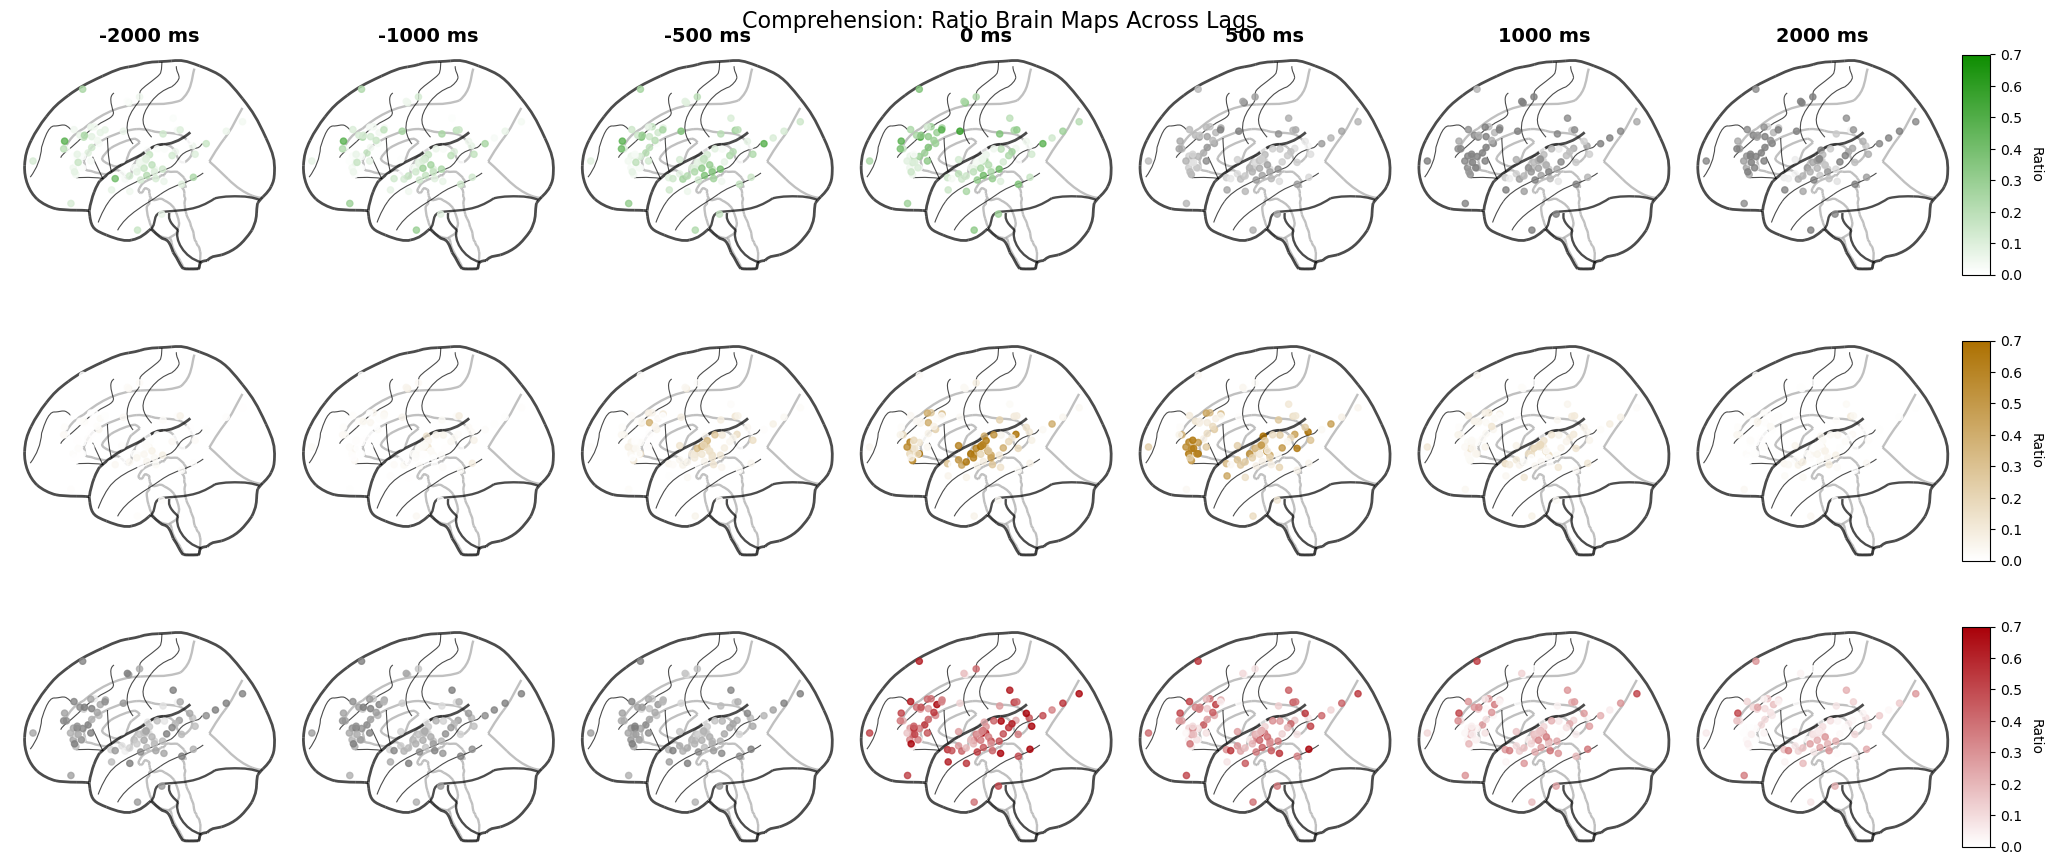

In [15]:
print("=" * 80)
print("PLOTTING COMPREHENSION RATIO BRAIN MAPS")
print("=" * 80)

# Define rows: future, word, past (ratio data)
ratio_data_comp = [
    (comp_future_ratio, 'Future/Joint', 'sentence'),
    (comp_word_ratio, 'Word/Joint', 'word'),
    (comp_past_ratio, 'Past/Joint', 'sentence2')
]

# Create figure with subplots - add one extra column for colorbar
n_rows = len(ratio_data_comp)
n_cols = len(lags_to_plot) + 1  # Add one column for colorbar
fig = plt.figure(figsize=(3 * len(lags_to_plot) + 1, 3 * n_rows))
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.3, wspace=0, 
                      width_ratios=[1] * len(lags_to_plot) + [0.1],
                      left=0.05, right=0.95, top=0.93, bottom=0.05)

# Set vmin and vmax for ratio plots
vmin_ratio = 0
vmax_ratio = 0.7

# Store axes from first row for positioning labels
first_row_axes = []

for row_idx, (df_ratio, row_name, label3) in enumerate(ratio_data_comp):
    for col_idx, lag in enumerate(lags_to_plot):
        # Get the actual lag value (not column name)
        actual_lag = lag_to_col_values[col_idx]
        
        # Add effect column using the actual lag value
        df_plot = add_effect_column(df_ratio, actual_lag, 'effect')
        
        # Get axis
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        # Store first row axes for later
        if row_idx == 0:
            first_row_axes.append(ax)

        # Set colormap for context highlighting
        if (label3 == 'sentence' and lag > 0) or (label3 == 'sentence2' and lag < 0):
            cmap = mcolors.LinearSegmentedColormap.from_list(
                f"{label3}_gray_cmap",
                ['white', 'grey'],
                N=256
            )
        else:
            cmap = colormaps[label3]
        
        # Plot glass brain without colorbar
        pu.plot_effect_glassbrain(
            df_plot,
            effect_col='effect',
            cmap=cmap,
            vmin=vmin_ratio,
            vmax=vmax_ratio,
            ax=ax,
            show=False,
            colorbar=False
        )
        
        # Remove axis margins
        ax.margins(0)
        
        print(f"  Plotted {row_name} at lag {lag}ms")
    
    # Add colorbar in the last column for this row
    cbar_ax = fig.add_subplot(gs[row_idx, -1])
    if label3 == 'sentence':
        cmap = colormaps['sentence']
    elif label3 == 'word':
        cmap = colormaps['word']
    else:
        cmap = colormaps['sentence2']
    
    norm = mcolors.Normalize(vmin=vmin_ratio, vmax=vmax_ratio)
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), 
                        cax=cbar_ax, orientation='vertical')
    cbar.set_label('Ratio', rotation=270, labelpad=15)

# Add column titles (lag labels) above the top row using stored axes
for col_idx, (lag, ax) in enumerate(zip(lags_to_plot, first_row_axes)):
    x_pos = ax.get_position().x0 + ax.get_position().width / 2
    fig.text(x_pos, 0.95, f"{lag} ms", ha='center', va='center', fontsize=14, weight='bold')

# Add a single title for the entire figure
plt.suptitle('Comprehension: Ratio Brain Maps Across Lags', fontsize=16, y=0.98)

# Save the figure
plt.savefig(f"{output_dir}/comprehension_ratio_brainmaps_across_lags.png", dpi=600, bbox_inches='tight')
print(f"\nSaved: {output_dir}/comprehension_ratio_brainmaps_across_lags.png")
plt.show()


## Plot Shifted Comprehension Ratio Brain Maps

PLOTTING SHIFTED COMPREHENSION RATIO BRAIN MAPS
  Plotted Future/Joint at lag -1650ms
  Plotted Future/Joint at lag -650ms


  Plotted Future/Joint at lag -150ms
  Plotted Future/Joint at lag 350ms
  Plotted Future/Joint at lag 850ms
  Plotted Future/Joint at lag 1350ms
  Plotted Future/Joint at lag 2350ms
  Plotted Word/Joint at lag -1650ms
  Plotted Word/Joint at lag -650ms
  Plotted Word/Joint at lag -150ms
  Plotted Word/Joint at lag 350ms
  Plotted Word/Joint at lag 850ms
  Plotted Word/Joint at lag 1350ms
  Plotted Word/Joint at lag 2350ms
  Plotted Past/Joint at lag -1650ms
  Plotted Past/Joint at lag -650ms
  Plotted Past/Joint at lag -150ms
  Plotted Past/Joint at lag 350ms
  Plotted Past/Joint at lag 850ms
  Plotted Past/Joint at lag 1350ms
  Plotted Past/Joint at lag 2350ms

Saved: /scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/future_past/bands_brainmaps/shifted_comprehension_ratio_brainmaps_across_lags.svg


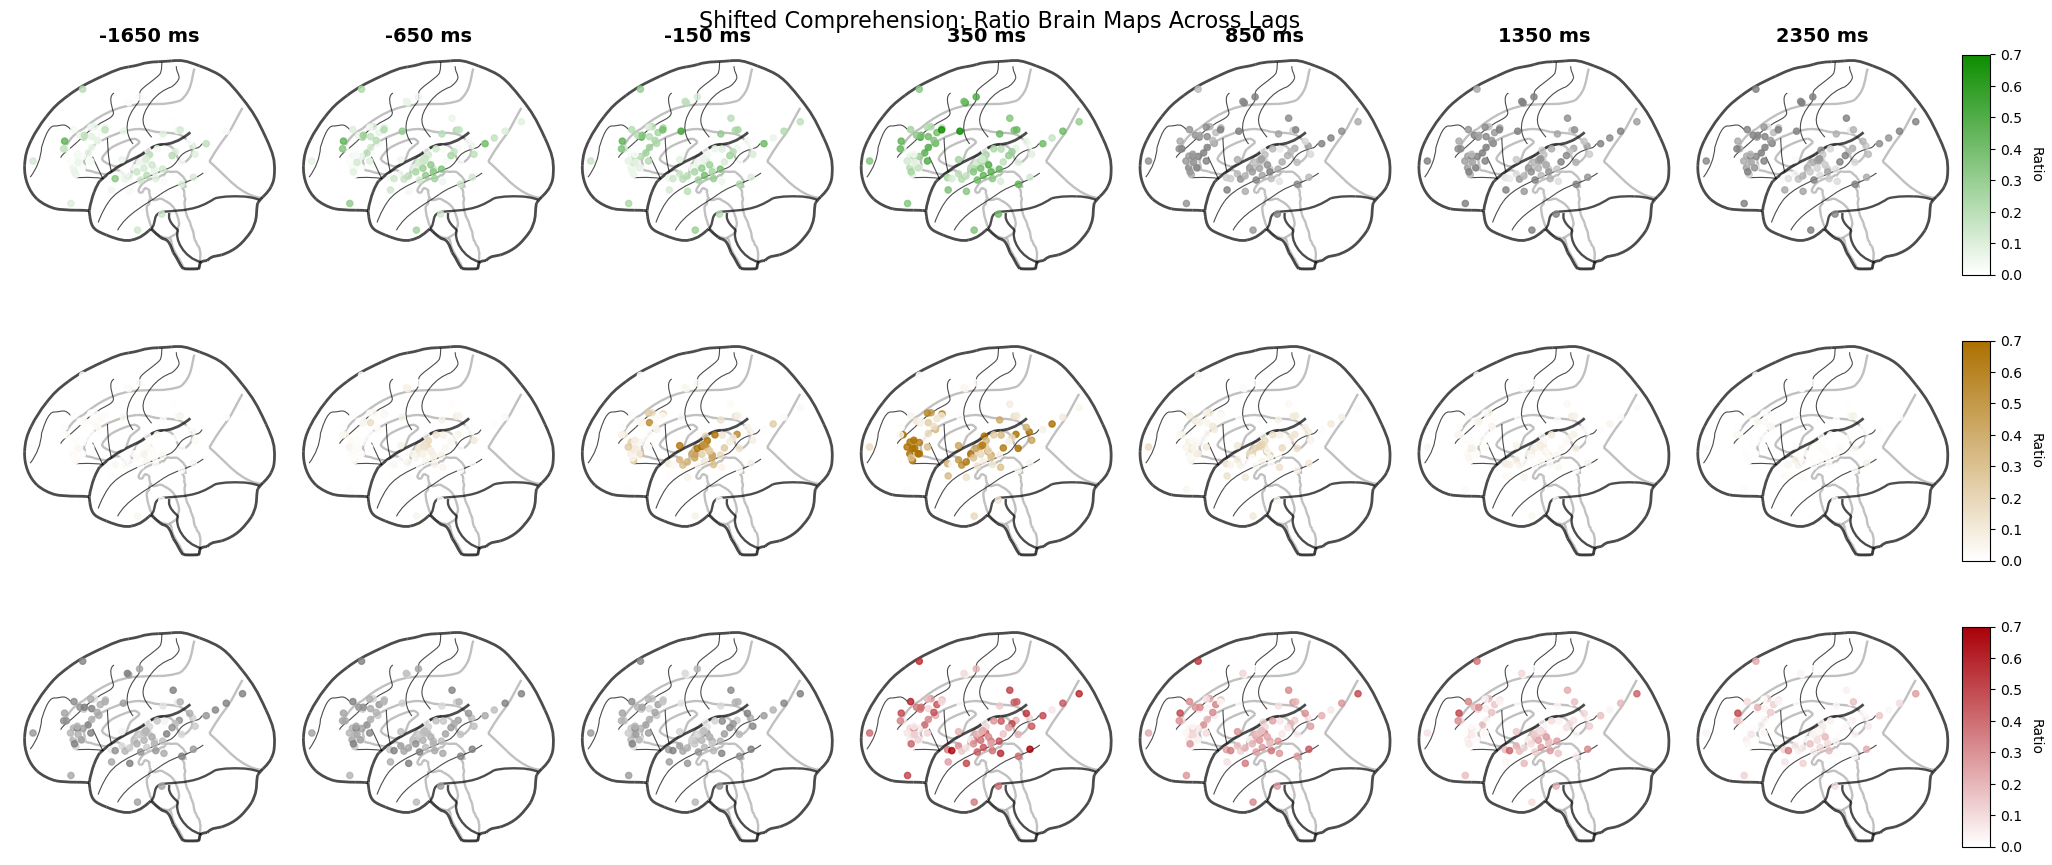

In [16]:
print("=" * 80)
print("PLOTTING SHIFTED COMPREHENSION RATIO BRAIN MAPS")
print("=" * 80)

# Define rows: future, word, past (shifted ratio data)
ratio_data_shifted_comp = [
    (shifted_comp_future_ratio, 'Future/Joint', 'sentence'),
    (shifted_comp_word_ratio, 'Word/Joint', 'word'),
    (shifted_comp_past_ratio, 'Past/Joint', 'sentence2')
]

# Create figure with subplots - add one extra column for colorbar
n_rows = len(ratio_data_shifted_comp)
n_cols = len(shifted_lags_to_plot) + 1  # Add one column for colorbar
fig = plt.figure(figsize=(3 * len(shifted_lags_to_plot) + 1, 3 * n_rows))
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.3, wspace=0, 
                      width_ratios=[1] * len(shifted_lags_to_plot) + [0.1],
                      left=0.05, right=0.95, top=0.93, bottom=0.05)

# Set vmin and vmax for ratio plots
vmin_ratio = 0
vmax_ratio = 0.7

# Store axes from first row for positioning labels
first_row_axes = []

for row_idx, (df_ratio, row_name, label3) in enumerate(ratio_data_shifted_comp):
    for col_idx, lag in enumerate(shifted_lags_to_plot):
        # Get the actual lag value (not column name)
        actual_lag = shifted_lag_columns[lag]
        
        # Add effect column using the actual lag value
        df_plot = add_effect_column(df_ratio, actual_lag, 'effect')
        
        # Get axis
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        # Store first row axes for later
        if row_idx == 0:
            first_row_axes.append(ax)

        # Set colormap for context highlighting
        if (label3 == 'sentence' and lag > 350) or (label3 == 'sentence2' and lag < 350):
            cmap = mcolors.LinearSegmentedColormap.from_list(
                f"{label3}_gray_cmap",
                ['white', 'grey'],
                N=256
            )
        else:
            cmap = colormaps[label3]
        
        # Plot glass brain without colorbar
        pu.plot_effect_glassbrain(
            df_plot,
            effect_col='effect',
            cmap=cmap,
            vmin=vmin_ratio,
            vmax=vmax_ratio,
            ax=ax,
            show=False,
            colorbar=False
        )
        
        # Remove axis margins
        ax.margins(0)
        
        print(f"  Plotted {row_name} at lag {lag}ms")
    
    # Add colorbar in the last column for this row
    cbar_ax = fig.add_subplot(gs[row_idx, -1])
    if label3 == 'sentence':
        cmap = colormaps['sentence']
    elif label3 == 'word':
        cmap = colormaps['word']
    else:
        cmap = colormaps['sentence2']
    
    norm = mcolors.Normalize(vmin=vmin_ratio, vmax=vmax_ratio)
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), 
                        cax=cbar_ax, orientation='vertical')
    cbar.set_label('Ratio', rotation=270, labelpad=15)

# Add column titles (lag labels) above the top row using stored axes
for col_idx, (lag, ax) in enumerate(zip(shifted_lags_to_plot, first_row_axes)):
    x_pos = ax.get_position().x0 + ax.get_position().width / 2
    fig.text(x_pos, 0.95, f"{lag} ms", ha='center', va='center', fontsize=14, weight='bold')

# Add a single title for the entire figure
plt.suptitle('Shifted Comprehension: Ratio Brain Maps Across Lags', fontsize=16, y=0.98)

# Save the figure
plt.savefig(f"{output_dir}/shifted_comprehension_ratio_brainmaps_across_lags.svg", bbox_inches='tight')
print(f"\nSaved: {output_dir}/shifted_comprehension_ratio_brainmaps_across_lags.svg")
plt.show()


## Plot Production Ratio Brain Maps

PLOTTING PRODUCTION RATIO BRAIN MAPS
  Plotted Future/Joint at lag -2000ms
  Plotted Future/Joint at lag -1000ms
  Plotted Future/Joint at lag -500ms
  Plotted Future/Joint at lag -1000ms
  Plotted Future/Joint at lag -500ms


  Plotted Future/Joint at lag 0ms
  Plotted Future/Joint at lag 500ms
  Plotted Future/Joint at lag 1000ms
  Plotted Future/Joint at lag 2000ms
  Plotted Word/Joint at lag -2000ms
  Plotted Future/Joint at lag 2000ms
  Plotted Word/Joint at lag -2000ms
  Plotted Word/Joint at lag -1000ms
  Plotted Word/Joint at lag -500ms
  Plotted Word/Joint at lag -1000ms
  Plotted Word/Joint at lag -500ms
  Plotted Word/Joint at lag 0ms
  Plotted Word/Joint at lag 500ms
  Plotted Word/Joint at lag 0ms
  Plotted Word/Joint at lag 500ms
  Plotted Word/Joint at lag 1000ms
  Plotted Word/Joint at lag 2000ms
  Plotted Word/Joint at lag 1000ms
  Plotted Word/Joint at lag 2000ms
  Plotted Past/Joint at lag -2000ms
  Plotted Past/Joint at lag -1000ms
  Plotted Past/Joint at lag -2000ms
  Plotted Past/Joint at lag -1000ms
  Plotted Past/Joint at lag -500ms
  Plotted Past/Joint at lag 0ms
  Plotted Past/Joint at lag -500ms
  Plotted Past/Joint at lag 0ms
  Plotted Past/Joint at lag 500ms
  Plotted Past/Joint 

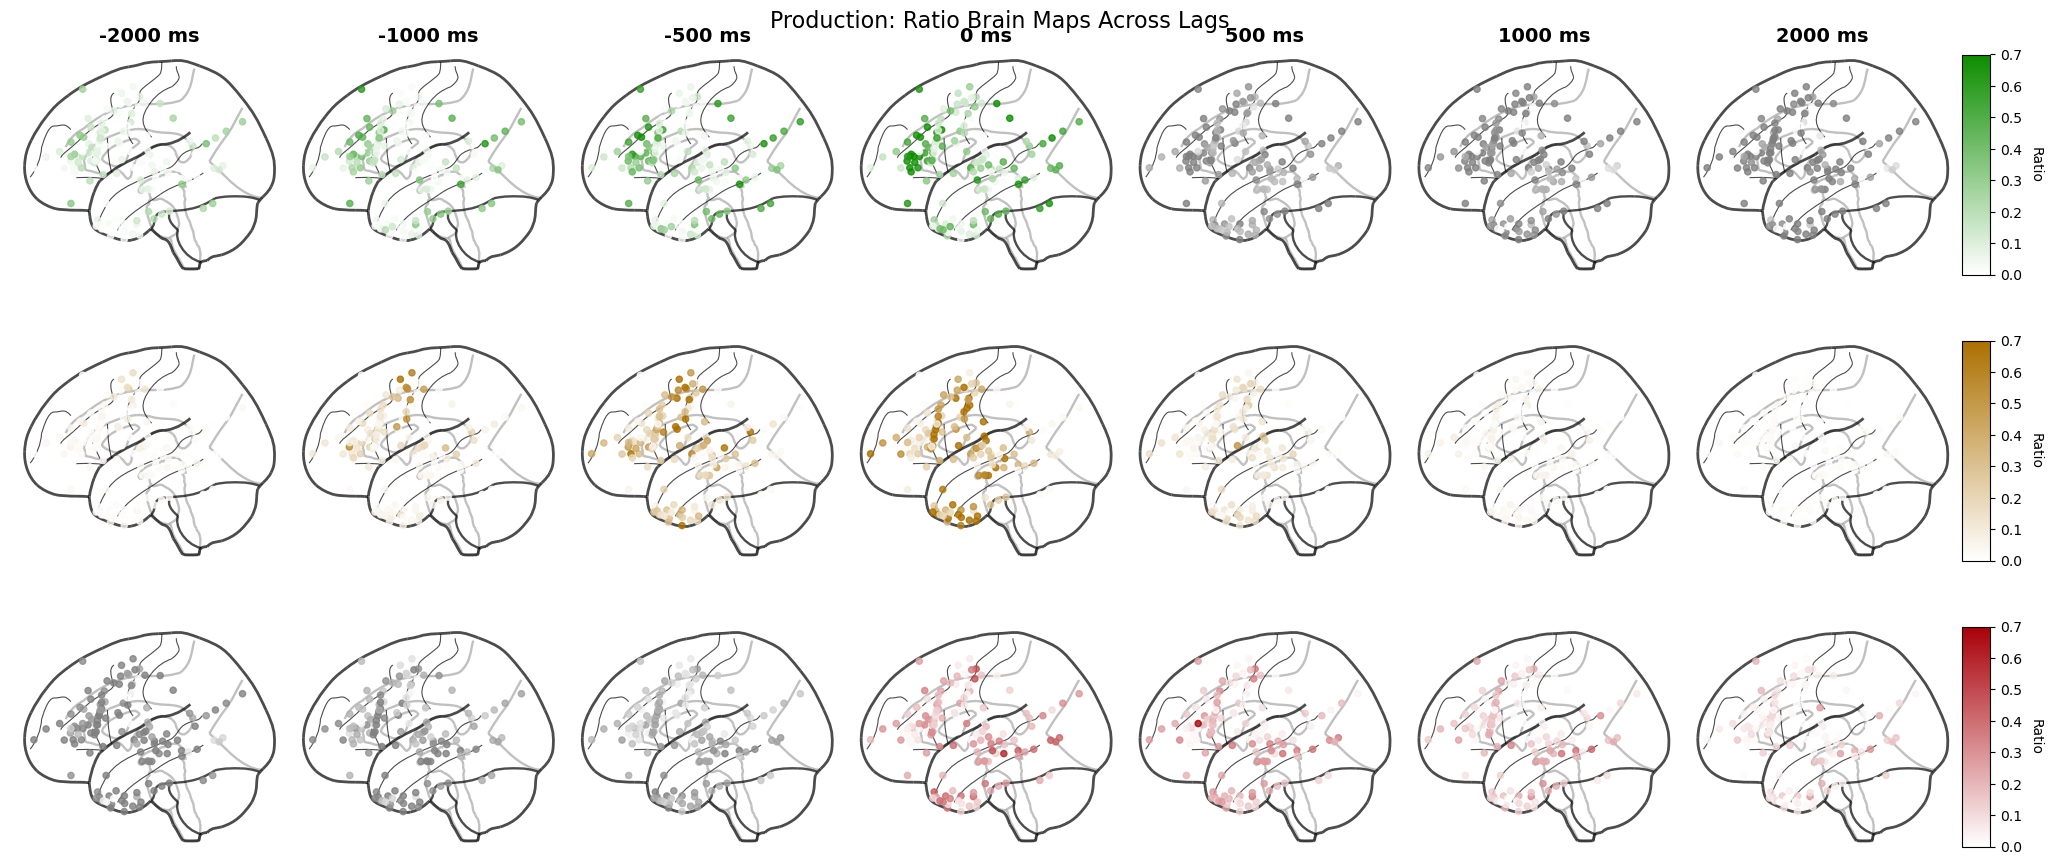

In [17]:
print("=" * 80)
print("PLOTTING PRODUCTION RATIO BRAIN MAPS")
print("=" * 80)

# Define rows: future, word, past (ratio data)
ratio_data_prod = [
    (prod_future_ratio, 'Future/Joint', 'sentence'),
    (prod_word_ratio, 'Word/Joint', 'word'),
    (prod_past_ratio, 'Past/Joint', 'sentence2')
]

# Create figure with subplots - add one extra column for colorbar
n_rows = len(ratio_data_prod)
n_cols = len(lags_to_plot) + 1  # Add one column for colorbar
fig = plt.figure(figsize=(3 * len(lags_to_plot) + 1, 3 * n_rows))
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.3, wspace=0, 
                      width_ratios=[1] * len(lags_to_plot) + [0.1],
                      left=0.05, right=0.95, top=0.93, bottom=0.05)

# Set vmin and vmax for ratio plots
vmin_ratio = 0
vmax_ratio = 0.7

# Store axes from first row for positioning labels
first_row_axes = []

for row_idx, (df_ratio, row_name, label3) in enumerate(ratio_data_prod):
    for col_idx, lag in enumerate(lags_to_plot):
        # Get the actual lag value (not column name)
        actual_lag = lag_to_col_values[col_idx]
        
        # Add effect column using the actual lag value
        df_plot = add_effect_column(df_ratio, actual_lag, 'effect')
        
        # Get axis
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        # Store first row axes for later
        if row_idx == 0:
            first_row_axes.append(ax)
        
        # Set colormap for context highlighting
        if (label3 == 'sentence' and lag > 0) or (label3 == 'sentence2' and lag < 0):
            cmap = mcolors.LinearSegmentedColormap.from_list(
                f"{label3}_gray_cmap",
                ['white', 'grey'],
                N=256
            )
        else:
            cmap = colormaps[label3]

        # Plot glass brain without colorbar
        pu.plot_effect_glassbrain(
            df_plot,
            effect_col='effect',
            cmap=cmap,
            vmin=vmin_ratio,
            vmax=vmax_ratio,
            ax=ax,
            show=False,
            colorbar=False
        )
        
        # Remove axis margins
        ax.margins(0)
        
        print(f"  Plotted {row_name} at lag {lag}ms")
    
    # Add colorbar in the last column for this row
    cbar_ax = fig.add_subplot(gs[row_idx, -1])
    if label3 == 'sentence':
        cmap = colormaps['sentence']
    elif label3 == 'word':
        cmap = colormaps['word']
    else:
        cmap = colormaps['sentence2']
    
    norm = mcolors.Normalize(vmin=vmin_ratio, vmax=vmax_ratio)
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), 
                        cax=cbar_ax, orientation='vertical')
    cbar.set_label('Ratio', rotation=270, labelpad=15)

# Add column titles (lag labels) above the top row using stored axes
for col_idx, (lag, ax) in enumerate(zip(lags_to_plot, first_row_axes)):
    x_pos = ax.get_position().x0 + ax.get_position().width / 2
    fig.text(x_pos, 0.95, f"{lag} ms", ha='center', va='center', fontsize=14, weight='bold')

# Add a single title for the entire figure
plt.suptitle('Production: Ratio Brain Maps Across Lags', fontsize=16, y=0.98)

# Save the figure
plt.savefig(f"{output_dir}/production_ratio_brainmaps_across_lags.png", dpi=600, bbox_inches='tight')
print(f"\nSaved: {output_dir}/production_ratio_brainmaps_across_lags.png")
plt.show()


## Sandbox

In [19]:
# future
future_ratio = ratio_data_prod[0][0].copy()
columns_to_drop = ['1160', '1180', '1190', '1210', '1220', '1240']
future_ratio = future_ratio.drop(columns=columns_to_drop, errors='ignore')
future_ratio.sort_values('1200', ascending=False, inplace=True)

future_ratio.tail(50)



,subject,electrode,roi,x,y,z,max_joint,1200
106,676,EEGDAMT_07REF,ctx-lh-middletemporal,-54.666667,-14.000000,-12.666667,0.147313,0.156945
96,676,EEGDAC_10REF,ctx-lh-parstriangularis,-49.333333,25.333333,6.666667,0.141592,0.153322
70,676,EEGG_06REF,preCG,-54.000000,1.000000,52.000000,0.240411,0.151690
81,676,EEGDAC_01REF,ctx-lh-caudalanteriorcingulate,-3.333333,20.000000,36.000000,0.164859,0.148968
93,676,EEGDPI_03REF,ctx-lh-insula,-45.200000,-11.200000,8.400000,0.152554,0.143967
103,676,EEGAF_08REF,rostralmiddlefrontal,-54.800000,47.600000,2.800000,0.153266,0.142864
111,676,EEGG_41REF,STG,-59.000000,16.666667,-23.333333,0.134757,0.139390
59,676,EEGDPMT_08REF,Left-Cerebral-White-Matter,-53.000000,-10.000000,-13.000000,0.154032,0.138859
8,798,G15,preCG,-57.000000,0.000000,51.000000,0.135728,0.136774
109,676,EEGG_15REF,postCG,-60.666667,-12.000000,50.666667,0.152154,0.135741
